In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
data = pd.read_csv('../M1_final.csv')

In [3]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [4]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

# data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


### Temporal lag feature

In [5]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified Train Test Split

In [6]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind Direction Transformer

In [7]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew Point Transformer

In [8]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [9]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition'])
], remainder='passthrough')

## XGBoost Model

In [10]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

## Create pipeline

In [11]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train XGBoost', xgboost_model)
])

## Hyperparameter tuning with Optuna

In [12]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import warnings

# Suppress warnings and Optuna's default logging to get clean progress bar
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.ERROR)

/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
def objective(trial):
    # Suppress warnings within the objective function as well
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Define hyperparameter search space
        params = {
            'Train XGBoost__n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'Train XGBoost__max_depth': trial.suggest_int('max_depth', 3, 10),
            'Train XGBoost__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'Train XGBoost__subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'Train XGBoost__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'Train XGBoost__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'Train XGBoost__gamma': trial.suggest_float('gamma', 0, 0.5),
            'Train XGBoost__reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
            'Train XGBoost__reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
        }
        
        # Set parameters to the pipeline
        pipe.set_params(**params)
        
        # Perform cross-validation
        # Using accuracy as the metric
        # n_jobs=1 to ensure proper progress display
        cv_scores = cross_val_score(
            pipe, 
            x_train, 
            y_train, 
            cv=5, 
            scoring='accuracy',
            n_jobs=1  # Single job to avoid multiprocessing hiding progress
        )
        
        # Return mean accuracy
        return cv_scores.mean()

In [14]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='XGBoost_WeatherOrder_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Suppress warnings during optimization for clean progress bar
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Run optimization
    study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=1)

print("\n" + "="*60)
print("Optimization Complete!")
print("="*60)

Best trial: 37. Best value: 0.97447: 100%|██████████| 50/50 [01:13<00:00,  1.47s/it] 


Optimization Complete!


## Results

In [15]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9745
  Number: 37

Best Hyperparameters:
  n_estimators: 258
  max_depth: 7
  learning_rate: 0.29756919903688084
  subsample: 0.775127002435905
  colsample_bytree: 0.9976493283501714
  min_child_weight: 2
  gamma: 0.36545792295227353
  reg_alpha: 0.3669024132392625
  reg_lambda: 0.8072948855490383


## Training the model with best hyper parameters

In [16]:
# Train final model with best parameters
best_params_with_prefix = {f'Train XGBoost__{key}': value for key, value in study.best_params.items()}
pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
pipe.fit(x_train, y_train)

Training final model with best parameters...


,steps,"[('Preprocessor', ...), ('Train XGBoost', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluating on test set

In [17]:
# Make predictions on test set
y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {100 * accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  98.8318
Precision: 0.9662
Recall:    0.9494
F1 Score:  0.9578


### Classification report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7440
           1       0.97      0.95      0.96      1206

    accuracy                           0.99      8646
   macro avg       0.98      0.97      0.98      8646
weighted avg       0.99      0.99      0.99      8646



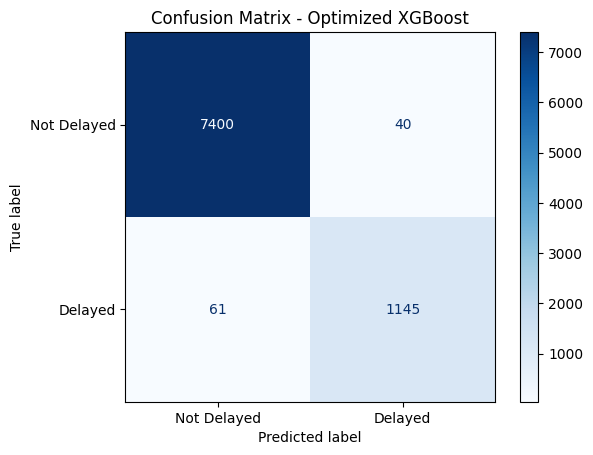

In [19]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized XGBoost')
plt.show()

## ROC AUC Score

ROC AUC Score: 99.8645


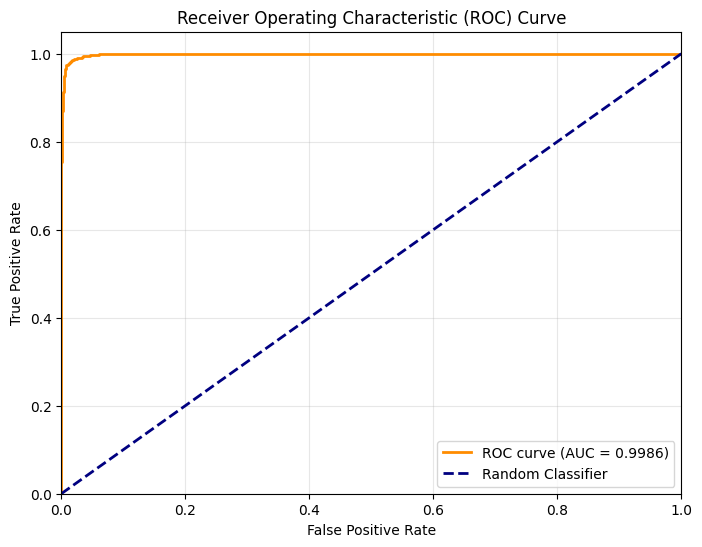

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Specificity and Sensitivity

In [21]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9946 or 99.46%
Sensitivity (True Positive Rate): 0.9494 or 94.94%


## Save the trained model

In [22]:
# import pickle
# import os
# from datetime import datetime

# # Create the saved_models directory if it doesn't exist
# save_dir = '../saved_models/'
# os.makedirs(save_dir, exist_ok=True)

# # Create a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# model_filename = os.path.join(save_dir, f'XGBoost_model_{timestamp}.pkl')

# # Save the entire pipeline (preprocessor + model)
# with open(model_filename, 'wb') as file:
#     pickle.dump(pipe, file)

# print(f"Model saved successfully as: {model_filename}")

# # Also save the best parameters for reference
# params_filename = os.path.join(save_dir, f'XGB_BestParams_JFKFlightTakeoff_{timestamp}.pkl')
# with open(params_filename, 'wb') as file:
#     pickle.dump(study.best_params, file)

# print(f"Best parameters saved as: {params_filename}")

### Load the model (example)
To load the model later, use the following code:

In [23]:
# # Example: How to load the saved model
# import pickle

# # Load the model
# with open('xgboost_model_YYYYMMDD_HHMMSS.pkl', 'rb') as file:
#     loaded_pipe = pickle.load(file)

# # Load the best parameters
# with open('best_params_YYYYMMDD_HHMMSS.pkl', 'rb') as file:
#     loaded_params = pickle.load(file)

# # Use the loaded model for predictions
# # predictions = loaded_pipe.predict(new_data)
# print("Model loaded successfully!")